# Phase 6, Milestone 2: exact prices for correlation derivatives

This notebook is the reproducible computational record for
`PHASE_6_MILESTONE_2_CORRELATION_DERIVATIVES.md`. It verifies, by
Monte Carlo, the closed-form prices of:

1. a **correlation digital** paying \(1_{\{\rho_T\ge\rho^*\}}\);
2. a **one-touch paid at expiry**, \(1_{\{\tau_\rho\le T\}}\);
3. a **one-touch paid at hit**, \(e^{-r\tau_\rho}1_{\{\tau_\rho\le T\}}\);
4. a **daily-monitored correlation range accrual**;

and plots the sensitivity of the one-touch price to the market price
of correlation risk (the risk-neutral drift shift). All Monte Carlo
uses exact Gaussian skeletons; barrier crossings use the drift-free
Brownian-bridge correction. Seed `20260727`, two step sizes where
discretization matters, standard errors reported.

In [1]:
from pathlib import Path
import json
import platform
import sys
import time

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import scipy

ROOT = Path.cwd().resolve()
if not (ROOT / "phase6_correlation.py").exists():
    candidates = [ROOT, *ROOT.parents]
    ROOT = next(path for path in candidates if (path / "phase6_correlation.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import phase6_correlation as p6

SEED = 20260727
rng = np.random.default_rng(SEED)

FIGURES = ROOT / "phase6_figures"
FIGURES.mkdir(exist_ok=True)

environment = {
    "python": platform.python_version(),
    "numpy": np.__version__,
    "scipy": scipy.__version__,
    "matplotlib": matplotlib.__version__,
    "platform": platform.platform(),
    "seed": SEED,
}
print(json.dumps(environment, indent=2))
started = time.time()

{
  "python": "3.12.13",
  "numpy": "2.5.1",
  "scipy": "1.18.0",
  "matplotlib": "3.11.1",
  "platform": "Linux-7.1.4-1-cachyos-x86_64-with-glibc2.43",
  "seed": 20260727
}


## 1. Market setup

Correlation is not traded, so pricing happens under a chosen
equivalent martingale measure; with a constant market price of
correlation risk \(\lambda\), only the drift changes,
\(\mu^{\mathbb Q}=\mu^{\mathbb P}+\sigma\lambda\), and every exact
formula of Milestone 1 survives with \(\mu\to\mu^{\mathbb Q}\)
(Milestone 2, §1). The prices below are therefore computed directly
under the risk-neutral drift.

In [2]:
SCALE = 1.0
X0 = 0.0
SIGMA = 0.8
MU_Q = 0.3          # risk-neutral drift of the conjugate factor
RATE = 0.05
RHO_STAR = 0.6
MATURITY = 1.5

rho0 = p6.rho_from_x(X0, scale=SCALE)
PARAMS = dict(rho0=rho0, drift=MU_Q, volatility=SIGMA, scale=SCALE, rate=RATE)
exact_prices = {
    "digital": p6.correlation_digital_price(RHO_STAR, maturity=MATURITY, **PARAMS),
    "touch_expiry": p6.one_touch_price_at_expiry(RHO_STAR, maturity=MATURITY, **PARAMS),
    "touch_hit": p6.one_touch_price_at_hit(RHO_STAR, maturity=MATURITY, **PARAMS),
}
for name, value in exact_prices.items():
    print(f"{name:>14}: {value:.6f}")
assert exact_prices["digital"] <= exact_prices["touch_expiry"] <= exact_prices["touch_hit"]

       digital: 0.352293
  touch_expiry: 0.559073
     touch_hit: 0.583426


## 2. Digital and one-touch prices vs. Monte Carlo

In [3]:
x_star = p6.x_from_rho(RHO_STAR, scale=SCALE)

def simulate_hitting_times(mu, n_paths, horizon, step, seed):
    # Estimated hitting times of x_star (NaN = not hit); alive-path filtering.
    local_rng = np.random.default_rng(seed)
    n_steps = int(round(horizon / step))
    state = np.full(n_paths, X0)
    alive_idx = np.arange(n_paths)
    hit_time = np.full(n_paths, np.nan)
    sd = SIGMA * np.sqrt(step)
    for k in range(n_steps):
        if state.size == 0:
            break
        old = state
        new = old + mu * step + sd * local_rng.standard_normal(old.size)
        gap_start = x_star - old
        gap_end = x_star - new
        crossed = gap_end <= 0.0
        both_below = (gap_start > 0.0) & (gap_end > 0.0)
        bridge_prob = np.zeros(old.size)
        bridge_prob[both_below] = np.exp(
            -2.0 * gap_start[both_below] * gap_end[both_below] / (SIGMA**2 * step)
        )
        crossed |= local_rng.random(old.size) < bridge_prob
        hit_time[alive_idx[crossed]] = (k + 0.5) * step
        alive_idx = alive_idx[~crossed]
        state = new[~crossed]
    return hit_time

N = 100_000
rows = []
for label, step in (("dt=1e-3", 1e-3), ("dt=3e-4", 3e-4)):
    hits = simulate_hitting_times(MU_Q, N, MATURITY, step, SEED)
    hit_mask = np.isfinite(hits)
    # Digital: terminal skeleton of the same simulation family (exact draw).
    x_terminal = X0 + MU_Q * MATURITY + SIGMA * np.sqrt(MATURITY) * rng.standard_normal(N)
    pay_digital = (x_terminal >= x_star).astype(float)
    # One-touch paid at expiry.
    pay_touch_expiry = hit_mask.astype(float)
    # One-touch paid at hit.
    pay_touch_hit = np.where(hit_mask, np.exp(-RATE * np.where(hit_mask, hits, 0.0)), 0.0)
    for name, pay, exact in (
        ("digital", pay_digital, exact_prices["digital"]),
        ("touch_expiry", pay_touch_expiry, exact_prices["touch_expiry"]),
        ("touch_hit", pay_touch_hit, exact_prices["touch_hit"]),
    ):
        discount = np.exp(-RATE * MATURITY) if name != "touch_hit" else 1.0
        estimate = discount * pay.mean()
        se = discount * pay.std(ddof=1) / np.sqrt(N)
        rows.append((name, label, exact, estimate, se, (estimate - exact) / se))

print(f"{'product':>14} {'scheme':>9} {'exact':>9} {'MC':>9} {'SE':>9} {'z':>6}")
for name, label, exact, estimate, se, z in rows:
    print(f"{name:>14} {label:>9} {exact:9.5f} {estimate:9.5f} {se:9.2e} {z:6.2f}")

       product    scheme     exact        MC        SE      z
       digital   dt=1e-3   0.35229   0.35121  1.42e-03  -0.76
  touch_expiry   dt=1e-3   0.55907   0.55871  1.44e-03  -0.25
     touch_hit   dt=1e-3   0.58343   0.58300  1.50e-03  -0.29
       digital   dt=3e-4   0.35229   0.35104  1.42e-03  -0.88
  touch_expiry   dt=3e-4   0.55907   0.56197  1.43e-03   2.02
     touch_hit   dt=3e-4   0.58343   0.58639  1.50e-03   1.98


## 3. Daily-monitored correlation range accrual

Payoff \(\sum_{i} 1_{\{\rho_\ell\le\rho_{t_i}\le\rho_h\}}\) at 60
equally spaced monitoring dates — the structure real range accruals
have. Exact price: a sum of Gaussian tail differences.

exact price : 27.711326
MC estimate : 27.769635 ± 0.091834 (2 SE)
z-score     : 1.27


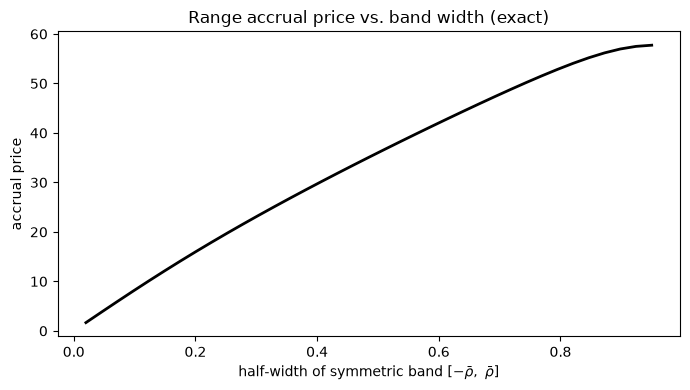

In [4]:
RHO_LOWER, RHO_UPPER = -0.2, 0.5
n_dates = 60
pay_dates = [MATURITY * (k + 1) / n_dates for k in range(n_dates)]
exact_accrual = p6.range_accrual_price(
    RHO_LOWER, RHO_UPPER, pay_dates=pay_dates, **PARAMS
)

x_lower = p6.x_from_rho(RHO_LOWER, scale=SCALE)
x_upper = p6.x_from_rho(RHO_UPPER, scale=SCALE)
dt_acc = MATURITY / n_dates
N_ACC = 100_000
state = np.full(N_ACC, X0)
discounted_count = np.zeros(N_ACC)
for date in pay_dates:
    state = state + MU_Q * dt_acc + SIGMA * np.sqrt(dt_acc) * rng.standard_normal(N_ACC)
    discounted_count += np.exp(-RATE * date) * ((state >= x_lower) & (state <= x_upper))
estimate = discounted_count.mean()
se = discounted_count.std(ddof=1) / np.sqrt(N_ACC)
print(f"exact price : {exact_accrual:.6f}")
print(f"MC estimate : {estimate:.6f} ± {2*se:.6f} (2 SE)")
print(f"z-score     : {(estimate - exact_accrual)/se:.2f}")

fig, ax = plt.subplots(figsize=(7, 4))
band_grid = np.linspace(0.02, 0.95, 37)
band_prices = [
    p6.range_accrual_price(-edge, edge, pay_dates=pay_dates, **PARAMS)
    for edge in band_grid
]
ax.plot(band_grid, band_prices, "k-", lw=2)
ax.set_xlabel(r"half-width of symmetric band $[-\bar\rho,\ \bar\rho]$")
ax.set_ylabel("accrual price")
ax.set_title("Range accrual price vs. band width (exact)")
fig.tight_layout()
fig.savefig(FIGURES / "phase6_range_accrual.png", dpi=150)
plt.show()

## 4. Sensitivity to the market price of correlation risk

Since the correlation factor is not traded, the risk-neutral drift
\(\mu^{\mathbb Q}=\mu^{\mathbb P}+\sigma\lambda\) is a free pricing
parameter. The one-touch price is an explicit function of it — no
re-simulation needed — which makes the correlation-risk-premium
sensitivity a closed-form comparative static.

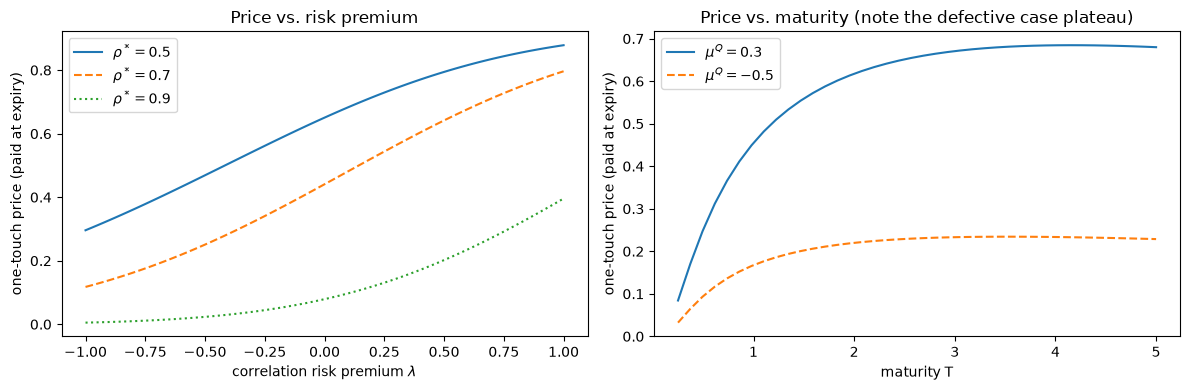

In [5]:
lambdas = np.linspace(-1.0, 1.0, 81)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for rho_star, style in ((0.5, "-"), (0.7, "--"), (0.9, ":")):
    prices = [
        p6.one_touch_price_at_expiry(
            rho_star, maturity=MATURITY,
            rho0=rho0, drift=MU_Q + SIGMA * lam,
            volatility=SIGMA, scale=SCALE, rate=RATE,
        )
        for lam in lambdas
    ]
    axes[0].plot(lambdas, prices, style, label=rf"$\rho^*={rho_star}$")
axes[0].set_xlabel(r"correlation risk premium $\lambda$")
axes[0].set_ylabel("one-touch price (paid at expiry)")
axes[0].legend()
axes[0].set_title("Price vs. risk premium")

horizons = np.linspace(0.25, 5.0, 40)
for mu_case, style in ((0.3, "-"), (-0.5, "--")):
    perpetual = [
        p6.one_touch_price_at_expiry(
            RHO_STAR, maturity=T,
            rho0=rho0, drift=mu_case,
            volatility=SIGMA, scale=SCALE, rate=RATE,
        )
        for T in horizons
    ]
    axes[1].plot(horizons, perpetual, style, label=rf"$\mu^Q={mu_case}$")
axes[1].set_xlabel("maturity T")
axes[1].set_ylabel("one-touch price (paid at expiry)")
axes[1].set_title("Price vs. maturity (note the defective case plateau)")
axes[1].legend()
fig.tight_layout()
fig.savefig(FIGURES / "phase6_touch_sensitivities.png", dpi=150)
plt.show()

## 5. Runtime and reproducibility record

In [6]:
print(f"total runtime: {time.time() - started:.1f} s")
print(json.dumps(environment, indent=2))

total runtime: 9.0 s
{
  "python": "3.12.13",
  "numpy": "2.5.1",
  "scipy": "1.18.0",
  "matplotlib": "3.11.1",
  "platform": "Linux-7.1.4-1-cachyos-x86_64-with-glibc2.43",
  "seed": 20260727
}
